In [1]:
import numpy as np
np.bool = np.bool_ 
import pandas as pd
import os
from tqdm import tqdm

import mxnet as mx
from mxnet import gluon
from mxnet import autograd
from mxnet import image

import sys

from sklearn.metrics import matthews_corrcoef
from scipy.stats import pearsonr

import random

import rasterio
from rasterio.enums import ColorInterp
from rasterio.features import shapes
from scipy import ndimage

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
%matplotlib inline

import higra as hg
import torch
import pickle

import itertools

import imageio.v3 as imageio
from skimage.color import label2rgb
import cv2
from skimage.segmentation import mark_boundaries
from skimage.segmentation import find_boundaries

from shapely.geometry import shape
import shapely
from shapely import Polygon, orient_polygons
from shapely.plotting import plot_polygon
from shapely import ops

import ast

import pyproj

import geopandas as gpd

import seaborn as sns

import matplotlib.font_manager as fm
import matplotlib.colors as colors

# Visualize field segmentations at different T values

In [2]:
sys.path.append('resuneta/src')
sys.path.append('decode/FracTAL_ResUNet/models/semanticsegmentation')
sys.path.append('decode/FracTAL_ResUNet/nn/loss')
sys.path.append('autogeobound/MXNet-ResUNeta/')
from bound_dist import get_distance, get_boundary
from FracTAL_ResUNet import FracTAL_ResUNet_cmtsk
from datasets import *

n_filters = 32
depth = 6
n_classes = 1
ctx = mx.cpu()
model = FracTAL_ResUNet_cmtsk(nfilters_init=n_filters, depth=depth, NClasses=n_classes)
model.load_parameters('experiments/8m-resolution/US/fractal-resunet_NAIP_nfilter-32_depth-6_bs-80_lr-0.001/model-20epoch.params', ctx=ctx)

depth:= 0, nfilters: 32, nheads::8, widths::1
depth:= 1, nfilters: 64, nheads::16, widths::1
depth:= 2, nfilters: 128, nheads::32, widths::1
depth:= 3, nfilters: 256, nheads::64, widths::1
depth:= 4, nfilters: 512, nheads::128, widths::1
depth:= 5, nfilters: 1024, nheads::256, widths::1
depth:= 6, nfilters: 512, nheads::256, widths::1
depth:= 7, nfilters: 256, nheads::128, widths::1
depth:= 8, nfilters: 128, nheads::64, widths::1
depth:= 9, nfilters: 64, nheads::32, widths::1
depth:= 10, nfilters: 32, nheads::16, widths::1


In [3]:
Ts = [0.01, 0.25, 0.5, 0.75]

image_filename = 'training_data/8m-resolution/US_NAIP_Semios/images/0000005.tif'
mask_filename = image_filename.replace("images", "masks")
image = imageio.imread(image_filename)[128:384, 128:384] # crop to center of image
rgb_img = image[:, :, :3]

image = np.moveaxis(image, -1, 0)[np.newaxis, :]
image = mx.nd.array(image).as_in_context(ctx)
_, bound, _ = model(image)
bound = bound.asnumpy()[0][0]

graph = hg.get_8_adjacency_graph((256, 256))
edge_weights = hg.weight_graph(graph,bound,hg.WeightFunction.mean)
tree, altitudes = hg.watershed_hierarchy_by_dynamics(graph, edge_weights)
pred_segmentations = []
for T in Ts:
    pred_segmentations.append(hg.labelisation_horizontal_cut_from_threshold(tree,altitudes,threshold=T).astype(float))

/tmp/ipykernel_1586578/485188551.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(image_filename)[128:384, 128:384] # crop to center of image
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")


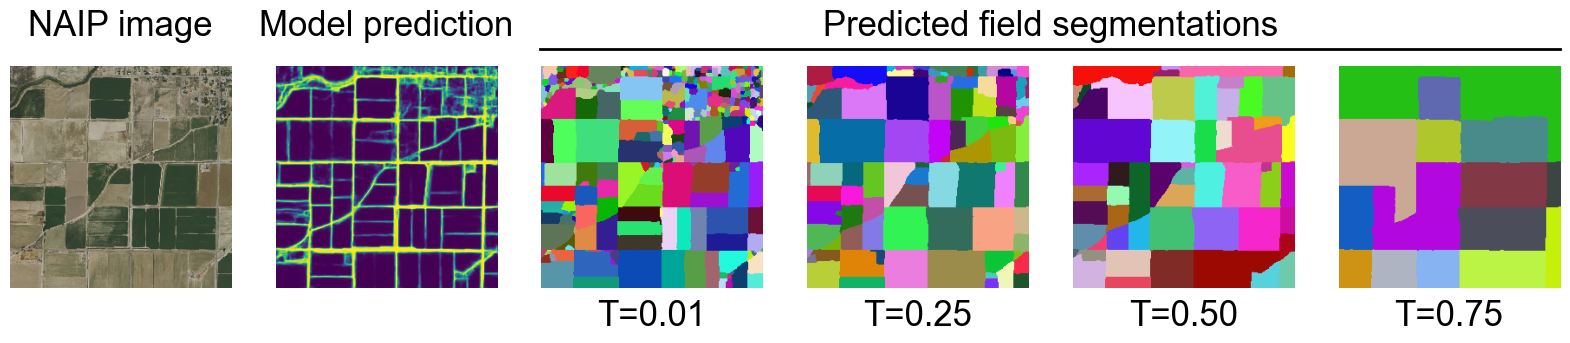

In [4]:
np.random.seed(0)
random.seed(0)

font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=25)          
plt.rc('axes', titlesize=25)     
plt.rc('axes', labelsize=25)    
plt.rc('xtick', labelsize=25)    
plt.rc('ytick', labelsize=25)    
plt.rc('figure', titlesize=25)

fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(20, 3))

ax = axs[0]
ax.set_axis_off()
ax.imshow(rgb_img)
ax.set_title('NAIP image', y=1.1)

'''
ax = axs[1]
ax.set_axis_off()
true_segmentation = rasterio.open(mask_filename).read()[0][128:384, 128:384]
unique_labels = np.unique(true_segmentation)
colors = [(np.random.rand(), np.random.rand(), np.random.rand()) for _ in unique_labels]
true_segmentation = label2rgb(true_segmentation, bg_label=0, bg_color=(0, 0, 0), colors=colors)
ax.imshow(true_segmentation)
'''

ax = axs[1]
ax.set_axis_off()
ax.imshow(bound)
ax.set_title('Model prediction', y=1.1)

for i, T in enumerate(Ts):
    ax = axs[2+i]
    ax.set_axis_off()
    pred_segmentation = pred_segmentations[i]
    unique_labels = np.unique(pred_segmentation)
    colors = [(np.random.rand(), np.random.rand(), np.random.rand()) for _ in unique_labels]
    pred_segmentation = label2rgb(pred_segmentation, bg_label=0, bg_color=(0, 0, 0), colors=colors)
    ax.imshow(pred_segmentation)
    ax.text(64, 300, f"T={T:.2f}", size=25)

    if i==1:
        ax.set_title("Predicted field segmentations", x=1.1, y=1.1)

line = Line2D([0.39, 0.9], [0.92, 0.92], color="black", linewidth=2, transform=fig.transFigure)
fig.add_artist(line)

plt.savefig('figures/watershed_algorithm.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Visualize calibration dataset

In [21]:
file = open('calibration_data/conformal_results_final.pkl', 'rb')
data = pickle.load(file)
file.close()

In [22]:
data["lon"] = data["lon_lat"].apply(lambda x: x[0])
data["lat"] = data["lon_lat"].apply(lambda x: x[1])
data["data_split"] = data["data_split"].apply(lambda x: 'holdout' if x=='test' else x)

/tmp/ipykernel_1586578/3445325303.py:51: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(image_filename)
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")


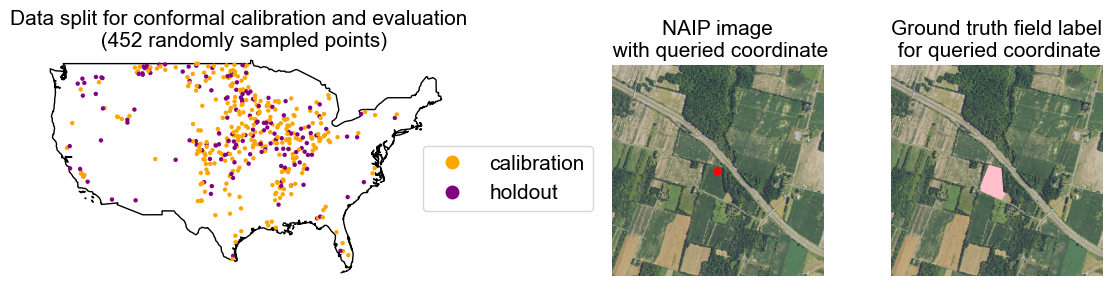

In [8]:
np.random.seed(0)
random.seed(0)

font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 0.7, 0.7]})

ax = axs[0]
world = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
usa = world[world.admin == "United States of America"]
usa.plot(ax=ax, color='white', edgecolor='black')
ax.set_xlim(-128, -65)
ax.set_ylim(23, 50)
gdf = gpd.GeoDataFrame(
    data[['lon', 'lat', 'data_split']], geometry=gpd.points_from_xy(data.lon, data.lat), crs="EPSG:4326"
)
gdf['data_split'] = pd.Categorical(gdf['data_split'], categories=['calibration', 'holdout'], ordered=True)
sc = gdf.plot(
    ax=ax,
    column='data_split',
    cmap=mcolors.ListedColormap(["orange", "purple"]),
    categorical=True,
    s=10,  
    alpha=1,
    linewidth=0,
    legend=True,
    legend_kwds={
        'frameon': True,
        'bbox_to_anchor':(0.9, 0.65),
    }
) 
ax.set_title('Data split for conformal calibration and evaluation \n (452 randomly sampled points)')
ax.set_axis_off()

ax = axs[1]
ax.set_axis_off()
ax.set_title('NAIP image\n with queried coordinate')
example_datapoint = data[data['data_split']=='calibration'].iloc[3]
image_filename = example_datapoint['image_filename']
coord = example_datapoint['sampled_coords']
image = imageio.imread(image_filename)
rgb_img = image[:, :, :3]
ax.imshow(rgb_img)
ax.plot(coord[1], coord[0], "o", color="red", markersize=5)
ax.set_xlim(coord[1]-128, coord[1]+128)
ax.set_ylim(coord[0]-128, coord[0]+128)

ax = axs[2]
ax.set_axis_off()
ax.set_title('Ground truth field label\n for queried coordinate')
ax.imshow(rgb_img)
src = rasterio.open(image_filename)
true_field = []
for x, y in example_datapoint['true_field_epsg5070'].exterior.coords:
    col, row = src.index(x, y)
    true_field.append((row, col))
true_field = Polygon(true_field)
plot_polygon(true_field, add_points=False, alpha=1, color='pink')
#ax.plot(coord[1], coord[0], "o", color="red", markersize=5)
ax.set_xlim(coord[1]-128, coord[1]+128)
ax.set_ylim(coord[0]-128, coord[0]+128)

plt.savefig('figures/calibration_and_holdout_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")


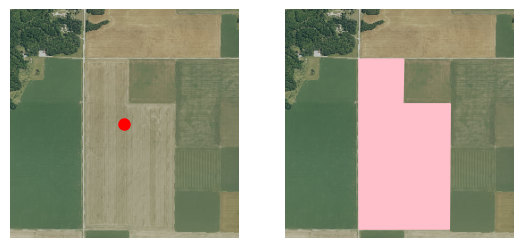

In [23]:
np.random.seed(0)
random.seed(0)

font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6.5, 3))

ax = axs[0]
ax.set_axis_off()
example_datapoint = data[data['data_split']=='calibration'].iloc[10]
image_filename = example_datapoint['image_filename']
coord = example_datapoint['sampled_coords']
image = imageio.imread(image_filename)
rgb_img = image[:, :, :3]
ax.imshow(rgb_img)
ax.plot(coord[1], coord[0], "o", color="red", markersize=8)
ax.set_xlim(coord[1]-128, coord[1]+128)
ax.set_ylim(coord[0]-128, coord[0]+128)

ax = axs[1]
ax.set_axis_off()
ax.imshow(rgb_img)
src = rasterio.open(image_filename)
true_field = []
for x, y in example_datapoint['true_field_epsg5070'].exterior.coords:
    col, row = src.index(x, y)
    true_field.append((row, col))
true_field = Polygon(true_field)
plot_polygon(true_field, add_points=False, alpha=1, color='pink')
#ax.plot(coord[1], coord[0], "o", color="red", markersize=5)
ax.set_xlim(coord[1]-128, coord[1]+128)
ax.set_ylim(coord[0]-128, coord[0]+128)

plt.savefig('figures/calibration_example.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Visualize training dataset

In [14]:
data = pd.read_csv('training_data/8m-resolution/US_points_final_8m.csv')

In [15]:
data['lat'] = data['.geo'].apply(lambda x: ast.literal_eval(x)["coordinates"][1])
data['lon'] = data['.geo'].apply(lambda x: ast.literal_eval(x)["coordinates"][0])
data = data[data['data_split'] != 'not_used']

/tmp/ipykernel_1586578/898443440.py:48: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(image_filename)
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")


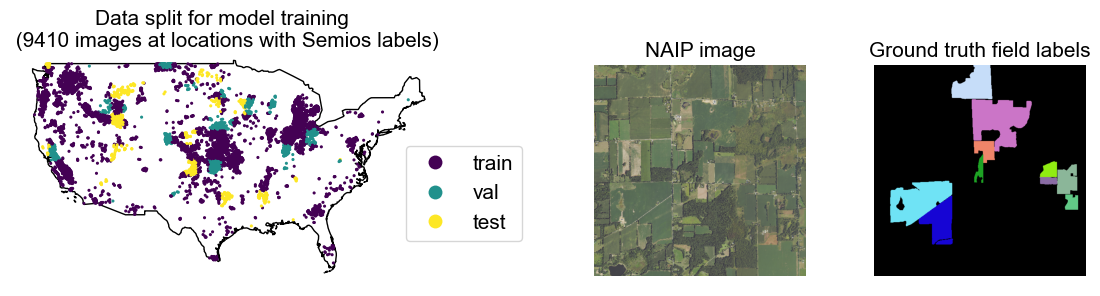

In [12]:
np.random.seed(0)
random.seed(0)

font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 3), gridspec_kw={'width_ratios': [2, 0.7, 0.7]})

ax = axs[0]
world = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
usa = world[world.admin == "United States of America"]
usa.plot(ax=ax, color='white', edgecolor='black')
ax.set_xlim(-128, -65)
ax.set_ylim(23, 50)
gdf = gpd.GeoDataFrame(
    data[['lon', 'lat', 'data_split']], geometry=gpd.points_from_xy(data.lon, data.lat), crs="EPSG:4326"
)
gdf['data_split'] = pd.Categorical(gdf['data_split'], categories=['train', 'val', 'test'], ordered=True)
sc = gdf.plot(
    ax=ax,
    column='data_split', 
    cmap=plt.get_cmap('viridis'),  
    categorical=True,
    s=5,  
    alpha=1,
    linewidth=0,
    legend=True,
    legend_kwds={
        'frameon': True,
        'bbox_to_anchor':(0.9, 0.65),
    }
) 
ax.set_title('Data split for model training \n (9410 images at locations with Semios labels)')
ax.set_axis_off()

ax = axs[1]
ax.set_axis_off()
image_filename = 'training_data/8m-resolution/US_NAIP_Semios/images/0007023.tif'
image = imageio.imread(image_filename)
rgb_img = image[:, :, :3]
ax.imshow(rgb_img)
ax.set_title('NAIP image')

ax = axs[2]
ax.set_axis_off()
mask_filename = image_filename.replace("images", "masks")
true_segmentation = rasterio.open(mask_filename).read()[0]
unique_labels = np.unique(true_segmentation)
colors = [(np.random.rand(), np.random.rand(), np.random.rand()) for _ in unique_labels]
true_segmentation = label2rgb(true_segmentation, bg_label=0, bg_color=(0, 0, 0), colors=colors)
ax.imshow(true_segmentation)
ax.set_title('Ground truth field labels')

plt.savefig('figures/training_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")


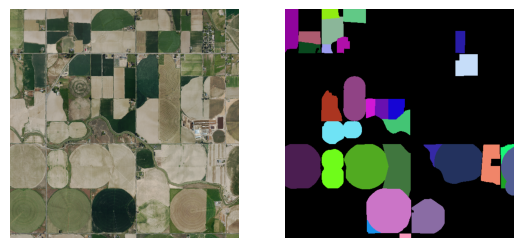

In [20]:
np.random.seed(0)
random.seed(0)

font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6.5, 3))

ax = axs[0]
ax.set_axis_off()
image_filename = 'training_data/8m-resolution/US_NAIP_Semios/images/0008012.tif'
image = imageio.imread(image_filename)
rgb_img = image[:, :, :3]
ax.imshow(rgb_img)

ax = axs[1]
ax.set_axis_off()
mask_filename = image_filename.replace("images", "masks")
true_segmentation = rasterio.open(mask_filename).read()[0]
unique_labels = np.unique(true_segmentation)
colors = [(np.random.rand(), np.random.rand(), np.random.rand()) for _ in unique_labels]
true_segmentation = label2rgb(true_segmentation, bg_label=0, bg_color=(0, 0, 0), colors=colors)
ax.imshow(true_segmentation)

plt.savefig('figures/training_example.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()